# Handwritten Digit Classifier: 0 vs 1 (Neural Network in TensorFlow)

A small neural network that looks at a handwritten digit and decides whether it is a **0** or a **1**.

**Dataset:** Kaggle's [Digit Recognizer](https://www.kaggle.com/c/digit-recognizer) (`train.csv`). Each image is 28×28 grayscale pixels, flattened into 784 numbers (0 to 255).

**What I did:**
1. Loaded the data and kept only the 0s and 1s
2. Scaled the pixels to 0-1
3. Split the data into 80% train / 20% test, by hand with NumPy
4. Built a 784 → 25 → 15 → 1 network (all sigmoid)
5. Trained it, then measured accuracy on images it had never seen

This is a practice project that rebuilds the idea from the Course 2 digit-recognition exercise on real Kaggle data. The split and the accuracy calculation are written by hand on purpose, to understand what each step does.

## 1. Setup

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

## 2. Load the data
Uploading `train.csv` from Kaggle (42,000 rows: one `label` column plus 784 pixel columns).

In [31]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [32]:
df = pd.read_csv('train.csv')

In [33]:
df.shape

(42000, 785)

In [34]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Keep only 0s and 1s
The full dataset has all ten digits. To keep this a **binary** classification problem (one sigmoid output), I filter to labels 0 and 1.

In [35]:
df_binary = df[(df['label'] == 0) | (df['label'] == 1)]

In [36]:
print(df_binary.shape)

(8816, 785)


## 4. Separate features and labels
- `X` = the 784 pixel columns (the input)
- `y` = the `label` column (the answer the model should learn)

In [37]:
X = df_binary.drop('label', axis=1)
y = df_binary['label']

In [38]:
print(X.shape)
print(y.shape)

(8816, 784)
(8816,)


## 5. Normalize the pixels
Pixel values run from 0 to 255. Dividing by 255 puts them between 0 and 1, which helps the network train more smoothly. The two prints below confirm the range is exactly 0 to 1.

In [39]:
X = X / 255.0

In [40]:
print(X.max().max())

1.0


In [41]:
print(X.min().min())

0.0


## 6. Look at one image
A row of `X` is 784 numbers. Reshaping it back to 28×28 and plotting it shows the handwritten digit. The label printed afterwards should match the picture.

In [42]:
one_image = X.iloc[3]

In [43]:
one_image = one_image.values.reshape(28, 28)

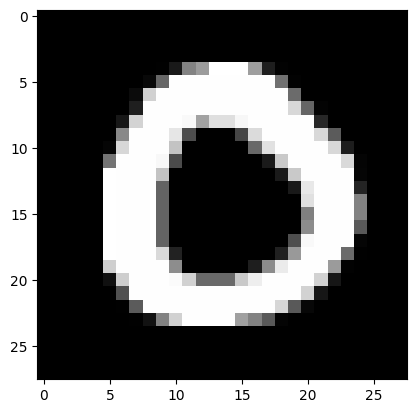

In [44]:
plt.imshow(one_image, cmap='gray')

In [45]:
print(y.iloc[3])


0


## 7. Train/test split (80% / 20%)
If I trained and tested on the same images, a high score would only prove the model memorized them. So I hold back 20% of the images that the model never sees during training and use them only for the final check.

Steps:
1. Make a shuffled list of row positions (`np.random.permutation`), so the split is random and not biased by the original file order
2. Cut the shuffled list at the 80% point (`split_point`)
3. Use `.iloc` to pull out `X_train`, `X_test`, `y_train`, `y_test`

Note: the numbers in `shuffled_indices` are **positions** of rows, not labels. `y` is where I look up what digit is at each position.

In [52]:
n = X.shape[0]
shuffled_indices = np.random.permutation(n)
print(shuffled_indices)

[1949 4848 3467 ... 6014 7686 4667]


In [54]:
split_point = int(0.8 * n)

In [60]:
train_indices = shuffled_indices[:split_point ]
test_indices = shuffled_indices[split_point :]

In [61]:
print(len(train_indices))
print(len(test_indices))

7052
1764


In [63]:
X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

Shapes check: rows should be 7052 and 1764, with 784 pixel columns in `X` and none in `y`. The `value_counts` below confirm both sets have a similar mix of 0s and 1s.

In [64]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7052, 784) (1764, 784) (7052,) (1764,)


In [65]:
y_train.value_counts()

,count
label,
1,3742
0,3310


In [66]:
y_test.value_counts()

,count
label,
1,942
0,822


## 8. Build the model
Architecture: **784 inputs → Dense(25) → Dense(15) → Dense(1)**, all with sigmoid activation.

- `Input(shape=(784,))` is the number of features per image (not the number of images)
- The last layer outputs one number between 0 and 1: the probability that the image is a **1**
- `model.summary()` shows 20,031 trainable parameters. For example, the first layer has 784 × 25 weights + 25 biases = 19,625

In [68]:
model = Sequential([
    Input(shape= (784,)),
    Dense(units= 25, activation= 'sigmoid'),
    Dense(units= 15, activation= 'sigmoid'),
    Dense(units= 1, activation= 'sigmoid'),
])

In [69]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,031 (78.25 KB)

 Trainable params: 20,031 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile and train
`compile` sets up how the model learns:
- **Loss:** `BinaryCrossentropy`, the standard loss for a sigmoid output with 0/1 labels
- **Optimizer:** `Adam` with learning rate 0.01, a smarter version of gradient descent

`fit` then trains on **only** `X_train` and `y_train`. One epoch is one full pass over the training images.

In [70]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate= 0.01)
)

In [72]:
model.fit(
    X_train,
    y_train,
    epochs= 10,
)

Epoch 1/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0477
Epoch 2/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0072
Epoch 3/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0024
Epoch 4/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0021
Epoch 5/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0016
Epoch 6/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0021
Epoch 7/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.3140e-04
Epoch 8/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9825e-04
Epoch 9/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.7621e-04
Epoch 10/10
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5376e-04


## 10. Evaluate on unseen data
`evaluate` scores the model on the held-out test set. The test loss is a bit higher than the final training loss, which is normal: the model does slightly better on images it studied than on new ones.

In [73]:
model.evaluate(X_test, y_test)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024    


0.002351214177906513

## 11. Turn probabilities into accuracy
Loss is hard to interpret, so I computed accuracy by hand:

1. `predict` gives a probability for each test image
2. Anything above 0.5 counts as a guess of **1**, otherwise **0**
3. Flatten the guesses so they line up one-to-one with `y_test` (shape `(1764, 1)` vs `(1764,)` would compare wrongly otherwise)
4. Compare guesses with the true labels. `matches.mean()` is the fraction of correct guesses

First, a check on 5 examples: the predictions are very close to 1 or 0 and agree with the labels.

In [74]:
predictions = model.predict(X_test)
print(predictions[:5])
print(y_test.iloc[:5])

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[9.9993140e-01]
 [9.2440598e-05]
 [9.9993116e-01]
 [9.9993390e-01]
 [9.9993354e-01]]
21545    1
24375    0
29533    1
1505     1
10392    1
Name: label, dtype: int64


In [75]:
print(predictions[:5] > 0.5)

[[ True]
 [False]
 [ True]
 [ True]
 [ True]]


In [77]:
guesses = predictions > 0.5
print(guesses.sum())

943


In [78]:
print(guesses.shape)
print(y_test.shape)

(1764, 1)
(1764,)


In [79]:
guesses = guesses.flatten()
print(guesses.shape)

(1764,)


In [80]:
matches = guesses == y_test.values
print(matches[:5])

[ True  True  True  True  True]


**Result:** the model got 1763 of 1764 test images right, about **99.94% accuracy**. (Exact numbers can differ slightly between runs because the shuffle is random.)

`matches.mean()` measures: the fraction of test images where the model's guess equals the real label. `True` counts as 1 and `False` as 0, so the average is the share of correct guesses. A value of 0.9994 means 1763 out of 1764 images were correct.

In [81]:
print(matches.sum())
print(matches.mean())

1763
0.9994331065759637


## 12. What the data looks like
One handwritten 0 and one handwritten 1 from the dataset, drawn by reshaping each row of 784 pixels back into a 28×28 grid.

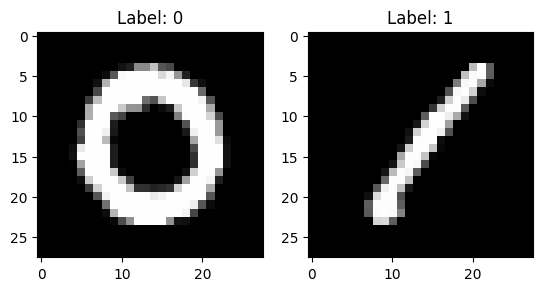

In [82]:
zero_img = X[y == 0].iloc[0].values.reshape(28, 28)
one_img = X[y == 1].iloc[0].values.reshape(28, 28)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(zero_img, cmap='gray')
axes[0].set_title('Label: 0')
axes[1].imshow(one_img, cmap='gray')
axes[1].set_title('Label: 1')
plt.show()

## Summary and limitations
- A small 784 → 25 → 15 → 1 sigmoid network separates handwritten 0s from 1s with about 99.94% accuracy on 1,764 images it never saw during training.
- This is **binary** (0 vs 1), which is an easy problem because the shapes look very different. Recognizing all ten digits would be the harder next step (softmax output, 10 classes).
- The split uses a random shuffle without a fixed seed, so exact results vary slightly per run.